In [ ]:
#!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pingouin]1/4 [xarray]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

/home/augusto/Development/Meta-Learning/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Passo 1: Obter conjunto de datasets de treinamento

In [ ]:
#Carregando os datasets
from sklearn.datasets import fetch_openml

names = ['diabetes', 'blood-transfusion-service-center',
         'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
         'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
         'cnae-9', 'ilpd-numeric', 'students_scores',
         'usps', 'ibm-employee-performance','mushroom',
         'segment',  'autoUniv-au1-1000', 'pizzacutter3',
         'qsar', 'solar-flare']

#Errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
#Too big: 'kits'

datasets = {}
for name in names:
    print('Fetching dataset: {}'.format(name))
    datasets[name] = fetch_openml(name=name, as_frame=True)

print(f'Finished fetching {len(datasets)} datasets.')


Fetching dataset: diabetes
Fetching dataset: blood-transfusion-service-center
Fetching dataset: monks-problems-2
Fetching dataset: tic-tac-toe
Fetching dataset: titanic
Fetching dataset: pc1
Fetching dataset: kr-vs-kp
Fetching dataset: phoneme
Fetching dataset: wdbc
Fetching dataset: semeion
Fetching dataset: isolet


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name diabetes exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=37
- version 5, status: active
  url: https://www.openml.org/search?type=data&id=42608

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name blood-transfusion-service-center exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1464
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=46913

  warn(warning_msg)
/opt/homebre

Fetching dataset: cnae-9
Fetching dataset: ilpd-numeric
Fetching dataset: students_scores
Fetching dataset: usps


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name cnae-9 exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1468
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41967

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ilpd-numeric exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=41943
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41945

  warn(warning_msg)
/opt/homebrew/Caskroom/minicond

Fetching dataset: ibm-employee-performance
Fetching dataset: mushroom
Fetching dataset: segment
Fetching dataset: autoUniv-au1-1000
Fetching dataset: pizzacutter3
Fetching dataset: qsar
Fetching dataset: solar-flare
Finished fetching 22 datasets.


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ibm-employee-performance exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=43895
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43897

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name mushroom exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=24
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=43922

  warn(warning_msg)
/opt/homebrew/Caskr

## Passo 2: Avaliar performance dos classificadores nos datasets

In [ ]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through datasets
for dataset_name in names:
    print(f'Processing dataset: {dataset_name}')

    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)

    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')

        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy',
                                    return_train_score=False)

        # Extract fold accuracies
        fold_accs = cv_results['test_score']

        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }

        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

Processing dataset: diabetes
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: blood-transfusion-service-center
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: monks-problems-2
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: tic-tac-toe
Falling back to simple imputation strategy.
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: titanic
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: pc1
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

...

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: autoUniv-au1-1000
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: pizzacutter3
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to s

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: qsar
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: solar-flare
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done


In [ ]:
# Saving results to CSV
performances_df.to_csv('classifier_performances.csv', index=False)

In [ ]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')


In [ ]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.020544,0.005750
1,diabetes,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.047810,0.024054
2,diabetes,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.006603,0.010406
3,diabetes,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.089839,0.006997
4,diabetes,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.012231,0.007863
...,...,...,...,...,...,...,...,...,...,...,...
127,solar-flare,SVM,0.746032,0.761905,0.730159,0.730159,0.714286,0.736508,0.016187,0.022030,0.009396
128,solar-flare,KNN,0.587302,0.714286,0.587302,0.730159,0.714286,0.666667,0.065060,0.005892,0.009568
129,solar-flare,LogisticRegression,0.714286,0.761905,0.730159,0.761905,0.682540,0.730159,0.030117,0.259444,0.008174
130,solar-flare,Perceptron,0.460317,0.666667,0.619048,0.539683,0.634921,0.584127,0.074721,0.023855,0.007233


## Passo 3: Extrair meta-features dos datasets

In [ ]:
# Extract meta-features
meta_features = []

for dataset_name in names:
    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']

    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)

    # Extract meta-features
    try:
        mfe = MFE(groups=["general", "statistical", "info-theory",
                          "clustering", #"concept", "model_based", "landmarking", "complexity",
                          ], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()

        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}

        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

Extracting meta-features from diabetes... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")


Done
Extracting meta-features from blood-transfusion-service-center... Done
Extracting meta-features from monks-problems-2... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1266: RuntimeWarning: invalid value encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1271: RuntimeWarning: invalid value encountered in log
  * np.log(np.linalg.det(pooled_cov_mat))


Done
Extracting meta-features from tic-tac-toe... 

...

Done
Extracting meta-features from qsar... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'g_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: The harmonic mean is only defined if all elements are non-negative; otherwise, the result is NaN.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'h_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/opt

Done
Extracting meta-features from solar-flare... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1266: RuntimeWarning: divide by zero encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices


Done


In [ ]:
# Saving meta-features to CSV
meta_features_df.to_csv('dataset_meta_features.csv', index=True)

In [ ]:
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [ ]:
meta_features_df

,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,cov.mean,...,sd.mean,sd_ratio,sil,skewness.mean,sparsity.mean,t_mean.mean,var.mean,vdb,vdu,w_lambda
diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,1.093502e+02,...,25.733743,1.032594,0.104260,0.527181,0.015923,40.209208,1.893059e+03,4.427474,3.677824e-08,6.967469e-01
blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,5.568267e+03,...,374.534549,1.082778,0.178546,2.254043,0.025118,267.449444,5.329470e+05,2.841441,0.000000e+00,8.709436e-01
monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,8.194676e-03,...,0.759888,NaN,-0.001832,-0.003244,0.373958,1.915974,6.221104e-01,16.096022,2.562547e-06,9.804071e-01
tic-tac-toe,0.014676,1.538037,0.009395,0.966025,NaN,19.371543,0.015851,0.930954,0.125923,2.937108e-02,...,0.481048,NaN,0.023668,0.524541,0.332637,0.294042,2.317603e-01,6.684681,2.083475e-06,6.679638e-02
titanic,0.054809,0.958873,0.001363,0.470040,0.0,236.113508,0.080603,0.907651,0.185447,1.856629e-01,...,1.000460,NaN,0.234431,0.683594,0.416402,0.151765,1.000920e+00,2.585854,0.000000e+00,7.790622e-01
pc1,0.216429,2.937619,0.018936,0.386223,0.0,15.547851,0.006607,0.363800,0.632733,9.113908e+06,...,8678.609589,NaN,0.620808,7.986854,0.012637,266.343759,1.391022e+09,2.173658,0.000000e+00,8.508315e-01
kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,1.123369e-02,...,0.332009,NaN,0.031625,4.108820,0.495212,0.224809,1.303675e-01,5.676987,8.009382e-08,3.602836e-01
phoneme,0.057846,4.025713,0.000925,0.497794,0.0,408.510486,0.010767,0.873182,0.126089,1.260889e-01,...,1.000000,1.234492,0.087266,0.779033,0.000010,-0.151914,1.000000e+00,3.102294,5.578544e-10,7.522012e-01
wdbc,0.052249,2.999956,0.052724,0.879957,0.0,633.631104,0.051585,0.952635,0.394897,6.764651e+02,...,34.904719,NaN,0.513697,1.731241,0.000209,53.294606,1.506322e+04,0.720645,3.317102e-08,2.256753e-01
semeion,0.031348,0.875007,0.160703,0.788536,0.0,41.251899,0.188329,3.321819,0.096662,2.013985e-02,...,0.455351,NaN,0.049640,0.807858,0.499686,0.222550,2.092574e-01,3.661805,1.756471e-05,3.074668e-05


# Passo 4: Combinar as meta-features e as performances

In [ ]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.020544,0.005750
1,diabetes,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.047810,0.024054
2,diabetes,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.006603,0.010406
3,diabetes,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.089839,0.006997
4,diabetes,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.012231,0.007863
...,...,...,...,...,...,...,...,...,...,...,...
127,solar-flare,SVM,0.746032,0.761905,0.730159,0.730159,0.714286,0.736508,0.016187,0.022030,0.009396
128,solar-flare,KNN,0.587302,0.714286,0.587302,0.730159,0.714286,0.666667,0.065060,0.005892,0.009568
129,solar-flare,LogisticRegression,0.714286,0.761905,0.730159,0.761905,0.682540,0.730159,0.030117,0.259444,0.008174
130,solar-flare,Perceptron,0.460317,0.666667,0.619048,0.539683,0.634921,0.584127,0.074721,0.023855,0.007233


In [ ]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,autoUniv-au1-1000,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000
1,blood-transfusion-service-center,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
2,cnae-9,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
3,diabetes,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
4,ibm-employee-performance,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259
5,ilpd-numeric,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557
6,isolet,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139
7,kr-vs-kp,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092
8,monks-problems-2,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204
9,mushroom,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399


In [ ]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df,
    left_on='Dataset',
    right_index=True,
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [ ]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,var.mean,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,autoUniv-au1-1000,0.004399,0.959212,0.020000,0.309874,0.0,4.879801,0.005145,0.825234,0.039626,...,2.366491e-01,12.510967,1.195378e-06,9.039781e-01,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000
1,blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,...,5.329470e+05,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
2,cnae-9,0.015155,0.050160,0.792593,0.975141,0.0,28.121009,0.034934,3.169925,0.009671,...,8.251032e-03,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
3,diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,...,1.893059e+03,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
4,ibm-employee-performance,0.049252,2.137001,0.022449,0.776640,0.0,0.230819,0.048857,0.619125,NaN,...,2.222840e+06,53.157342,1.962878e-08,3.968296e-01,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259
5,ilpd-numeric,0.046057,2.677291,0.017153,0.346650,0.0,16.420895,0.012178,0.864090,0.179914,...,1.761536e+04,2.361913,7.079625e-09,8.798338e-01,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557
6,isolet,0.018233,3.902519,0.079133,0.776810,0.0,273.604499,0.072781,4.700438,0.173298,...,1.862294e-01,3.695307,2.533339e-06,1.357282e-14,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139
7,kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,...,1.303675e-01,5.676987,8.009382e-08,3.602836e-01,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092
8,monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,...,6.221104e-01,16.096022,2.562547e-06,9.804071e-01,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204
9,mushroom,0.105408,1.409255,0.002708,1.000000,NaN,1075.059896,0.127349,0.999068,0.095319,...,9.336038e-02,2.727542,1.858092e-08,5.773160e-15,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399


In [ ]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

In [ ]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,autoUniv-au1-1000,0.004399,0.959212,0.020000,0.309874,0.0,4.879801,0.005145,0.825234,0.039626,...,12.510967,1.195378e-06,9.039781e-01,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM
1,blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,...,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression
2,cnae-9,0.015155,0.050160,0.792593,0.975141,0.0,28.121009,0.034934,3.169925,0.009671,...,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP
3,diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,...,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression
4,ibm-employee-performance,0.049252,2.137001,0.022449,0.776640,0.0,0.230819,0.048857,0.619125,NaN,...,53.157342,1.962878e-08,3.968296e-01,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259,DecisionTree
5,ilpd-numeric,0.046057,2.677291,0.017153,0.346650,0.0,16.420895,0.012178,0.864090,0.179914,...,2.361913,7.079625e-09,8.798338e-01,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557,LogisticRegression
6,isolet,0.018233,3.902519,0.079133,0.776810,0.0,273.604499,0.072781,4.700438,0.173298,...,3.695307,2.533339e-06,1.357282e-14,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139,MLP
7,kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,...,5.676987,8.009382e-08,3.602836e-01,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092,DecisionTree
8,monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,...,16.096022,2.562547e-06,9.804071e-01,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204,DecisionTree
9,mushroom,0.105408,1.409255,0.002708,1.000000,NaN,1075.059896,0.127349,0.999068,0.095319,...,2.727542,1.858092e-08,5.773160e-15,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399,DecisionTree


In [ ]:
pd.DataFrame(meta_dataset['Best'].value_counts())

,count
Best,
MLP,6
DecisionTree,6
LogisticRegression,5
SVM,4
KNN,1


# Passo 5: Treinar (e avaliar) o meta-modelo

In [ ]:
# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = meta_dataset['Best'].values
y_pred = []
meta_model_train_time = 0.0
meta_model_test_time = 0.0

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train)
    meta_model_train_time += time() - t0

    # Predict the best classifier for the test dataset
    t0 = time()
    y_pred.append(clf.predict(X_test)[0])
    meta_model_test_time += time() - t0

    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
summary_df = pd.DataFrame(summary_of_predictions)

# Calculate and store meta-model metrics
meta_model_base_perf = summary_df['Perf of best clf (pred)'].mean()
meta_model_accuracy = accuracy_score(y_true, y_pred)
meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')
print(f'Training time (s): {meta_model_train_time:.4f}')
print(f'Testing time (s): {meta_model_test_time:.4f}')
print(f'Base perf: {meta_model_base_perf:.4f}')


Meta-model Accuracy: 0.23
Meta-model F1-score: 0.22
Training time (s): 0.0557
Testing time (s): 0.0252
Base perf: 0.8542


In [ ]:
summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.651000
1,blood-transfusion-service-center,LogisticRegression,0.772707,LogisticRegression,0.772707
2,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,LogisticRegression,0.770792,DecisionTree,0.700433
4,ibm-employee-performance,DecisionTree,1.000000,LogisticRegression,0.961224
5,ilpd-numeric,LogisticRegression,0.718700,LogisticRegression,0.718700
6,isolet,MLP,0.961396,SVM,0.961139
7,kr-vs-kp,DecisionTree,0.995620,MLP,0.993742
8,monks-problems-2,DecisionTree,0.991667,MLP,0.750441
9,mushroom,DecisionTree,1.000000,DecisionTree,1.000000


In [ ]:
# Base-level performance:
summary_df.describe()


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.854170
std,0.094263,0.107603
min,0.718700,0.651000
25%,0.812109,0.756007
50%,0.925093,0.866407
75%,0.963726,0.955594
max,1.000000,1.000000


In [ ]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop])
final_summary

,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM,0.758000,DecisionTree,0.651000
1,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression,0.772707,LogisticRegression,0.772707
2,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP,0.955556,DecisionTree,0.864815
3,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression,0.770792,DecisionTree,0.700433
4,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259,DecisionTree,1.000000,LogisticRegression,0.961224
5,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557,LogisticRegression,0.718700,LogisticRegression,0.718700
6,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139,MLP,0.961396,SVM,0.961139
7,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092,DecisionTree,0.995620,MLP,0.993742
8,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204,DecisionTree,0.991667,MLP,0.750441
9,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399,DecisionTree,1.000000,DecisionTree,1.000000


<Axes: >

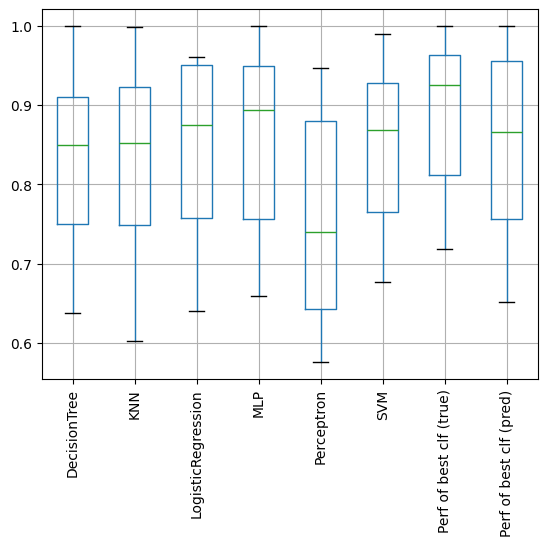

In [ ]:
final_summary.boxplot(rot=90)

# Passo 6: Treinar (e Avaliar) o modelo usando Rankings

## Passo 6.1: Abordagem 1

In [ ]:
# Create a dictionary to store the results
summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
y_true_best = []
y_pred_best = []
rank_ab1_train_time = 0.0
rank_ab1_test_time = 0.0
rank_ab1_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset[classifier_cols]  # multi-output regression target (one score per classifier)

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train regressor to predict classifier performances
    clf = DecisionTreeRegressor(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train)
    rank_ab1_train_time += time() - t0

    # Predicted performances for each classifier on the test dataset
    t0 = time()
    pred_scores = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_scores.idxmax()
    rank_ab1_test_time += time() - t0

    # True performances for each classifier on the test dataset
    true_scores = y_test.iloc[0]
    true_best_clf = true_scores.idxmax()

    # Spearman rank correlation (SRC) between predicted and true classifier score vectors
    fold_src = pred_scores.corr(true_scores, method='spearman')
    rank_ab1_src_values.append(fold_src)

    y_true_best.append(true_best_clf)
    y_pred_best.append(pred_best_clf)

    # Store results in summary dictionary
    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    summary_of_predictions['Dataset'].append(dataset_name)
    summary_of_predictions['Best clf (true)'].append(true_best_clf)
    summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    # performance obtained by selecting the predicted best classifier
    summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

# Create a DataFrame from the summary of predictions
rank_ab1_summary_df = pd.DataFrame(summary_of_predictions)

# Calculate and store meta-model metrics over predicted best-classifier labels
rank_ab1_base_perf = rank_ab1_summary_df['Perf of best clf (pred)'].mean()
rank_ab1_meta_model_accuracy = accuracy_score(y_true_best, y_pred_best)
rank_ab1_meta_model_f1 = f1_score(y_true_best, y_pred_best, average='weighted')
rank_ab1_src = np.nanmean(rank_ab1_src_values)
print(f'Meta-model Accuracy: {rank_ab1_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {rank_ab1_meta_model_f1:.2f}')
print(f'Training time (s): {rank_ab1_train_time:.4f}')
print(f'Testing time (s): {rank_ab1_test_time:.4f}')
print(f'Base perf: {rank_ab1_base_perf:.4f}')
print(f'SRC: {rank_ab1_src:.4f}')

Meta-model Accuracy: 0.23
Meta-model F1-score: 0.22
Training time (s): 0.0786
Testing time (s): 0.0368
Base perf: 0.8385
SRC: 0.3761


In [ ]:
rank_ab1_summary_df.describe()

,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.838456
std,0.094263,0.112997
min,0.718700,0.673249
25%,0.812109,0.740529
50%,0.925093,0.862265
75%,0.963726,0.949047
max,1.000000,0.995620


## Passo 6.2: Abordagem 2

In [ ]:
# Create a dictionary to store the results
summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
y_true_best = []
y_pred_best = []
rank_ab2_train_time = 0.0
rank_ab2_test_time = 0.0
rank_ab2_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)

    # Raw classifier performances (for reporting obtained performance)
    y_raw = meta_dataset[classifier_cols]

    # Convert classifier performances to ranks per dataset (1 = best classifier)
    y_rank = y_raw.rank(axis=1, ascending=False, method='average')

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_rank = y_rank.iloc[train_index]
    y_test_rank = y_rank.iloc[test_index]
    y_test_raw = y_raw.iloc[test_index]

    # Train regressor to predict classifier ranks
    clf = DecisionTreeRegressor(random_state=42)
    t0 = time()
    clf.fit(X_train, y_train_rank)
    rank_ab2_train_time += time() - t0

    # Predicted ranks for each classifier on the test dataset
    t0 = time()
    pred_ranks = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_ranks.idxmin()
    rank_ab2_test_time += time() - t0

    # True ranks for each classifier on the test dataset
    true_ranks = y_test_rank.iloc[0]
    true_best_clf = true_ranks.idxmin()
    true_scores = y_test_raw.iloc[0]

    # Spearman rank correlation (SRC) between predicted and true rank vectors
    fold_src = pred_ranks.corr(true_ranks, method='spearman')
    rank_ab2_src_values.append(fold_src)

    y_true_best.append(true_best_clf)
    y_pred_best.append(pred_best_clf)

    # Store results in summary dictionary
    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    summary_of_predictions['Dataset'].append(dataset_name)
    summary_of_predictions['Best clf (true)'].append(true_best_clf)
    summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

# Create a DataFrame from the summary of predictions
rank_ab2_summary_df = pd.DataFrame(summary_of_predictions)

# Calculate and store meta-model metrics over predicted best-classifier labels
rank_ab2_base_perf = rank_ab2_summary_df['Perf of best clf (pred)'].mean()
rank_ab2_meta_model_accuracy = accuracy_score(y_true_best, y_pred_best)
rank_ab2_meta_model_f1 = f1_score(y_true_best, y_pred_best, average='weighted')
rank_ab2_src = np.nanmean(rank_ab2_src_values)
print(f'Meta-model Accuracy (rank target): {rank_ab2_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score (rank target): {rank_ab2_meta_model_f1:.2f}')
print(f'Training time (s): {rank_ab2_train_time:.4f}')
print(f'Testing time (s): {rank_ab2_test_time:.4f}')
print(f'Base perf: {rank_ab2_base_perf:.4f}')
print(f'SRC: {rank_ab2_src:.4f}')

rank_ab2_summary_df.describe()

Meta-model Accuracy (rank target): 0.23
Meta-model F1-score (rank target): 0.23
Training time (s): 0.1326
Testing time (s): 0.0666
Base perf: 0.8436
SRC: 0.4106


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.843604
std,0.094263,0.112140
min,0.718700,0.651000
25%,0.812109,0.756984
50%,0.925093,0.861027
75%,0.963726,0.947348
max,1.000000,1.000000


# Passo 7: Comparar Resultados

In [ ]:
comparison_table = pd.DataFrame([
    {
        'Model': "Decision Tree (Classification)",
        'Base perf': meta_model_base_perf,
        'Acc': meta_model_accuracy,
        'F1': meta_model_f1,
        'SRC': np.nan,
        'Training time (s)': meta_model_train_time,
        'Testing time (s)': meta_model_test_time,
    },
    {
        'Model': "Decision Tree Rank (Regression on performance)",
        'Base perf': rank_ab1_base_perf,
        'Acc': rank_ab1_meta_model_accuracy,
        'F1': rank_ab1_meta_model_f1,
        'SRC': rank_ab1_src,
        'Training time (s)': rank_ab1_train_time,
        'Testing time (s)': rank_ab1_test_time,
    },
    {
        'Model': "Decision Tree Rank (Regression on ranks)",
        'Base perf': rank_ab2_base_perf,
        'Acc': rank_ab2_meta_model_accuracy,
        'F1': rank_ab2_meta_model_f1,
        'SRC': rank_ab2_src,
        'Training time (s)': rank_ab2_train_time,
        'Testing time (s)': rank_ab2_test_time,
    },
])

comparison_table[['Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)']] = comparison_table[
    ['Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)']
] .round(4)

comparison_table

,Model,Base perf,Acc,F1,SRC,Training time (s),Testing time (s)
0,Decision Tree (Classification),0.8542,0.2273,0.2231,NaN,0.0557,0.0252
1,Decision Tree Rank (Regression on performance),0.8385,0.2273,0.2240,0.3761,0.0786,0.0368
2,Decision Tree Rank (Regression on ranks),0.8436,0.2273,0.2271,0.4106,0.1326,0.0666


In [ ]:
# Passo 8: Matrizes para teste de normalidade

# 1) Matriz pareada para performance em nível base
# Inclui as três abordagens: DT classificação (Passo 5), Ranking Ab1 e Ranking Ab2
base_perf_matrix = (
    summary_df[['Dataset', 'Perf of best clf (pred)']]
    .rename(columns={'Perf of best clf (pred)': 'base_perf_dt'})
    .merge(
        rank_ab1_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_ab1'}),
        on='Dataset',
        how='inner'
    )
    .merge(
        rank_ab2_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_ab2'}),
        on='Dataset',
        how='inner'
    )
)

# 2) Matriz pareada para SRC por dataset (Ab1 vs Ab2)
# Assumindo que rank_ab1_src_values e rank_ab2_src_values seguem a mesma ordem de datasets dos summaries
src_matrix = rank_ab1_summary_df[['Dataset']].copy()
src_matrix['src_ab1'] = np.array(rank_ab1_src_values, dtype=float)
src_matrix = src_matrix.merge(
    rank_ab2_summary_df[['Dataset']].assign(src_ab2=np.array(rank_ab2_src_values, dtype=float)),
    on='Dataset',
    how='inner'
)

# Salvar para uso em testes de normalidade
base_perf_matrix.to_csv('normality_matrix_base_perf.csv', index=False)
src_matrix.to_csv('normality_matrix_src.csv', index=False)

print('Arquivos salvos: normality_matrix_base_perf.csv, normality_matrix_src.csv')
print(f'base_perf_matrix shape: {base_perf_matrix.shape}')
print(f'src_matrix shape: {src_matrix.shape}')

base_perf_matrix.head(), src_matrix.head()

Arquivos salvos: normality_matrix_base_perf.csv, normality_matrix_src.csv
base_perf_matrix shape: (22, 4)
src_matrix shape: (22, 3)


(                            Dataset  base_perf_dt  base_perf_ab1  \
 0                 autoUniv-au1-1000      0.651000       0.703000   
 1  blood-transfusion-service-center      0.772707       0.673942   
 2                            cnae-9      0.864815       0.864815   
 3                          diabetes      0.700433       0.770792   
 4          ibm-employee-performance      0.961224       0.961224   
 
    base_perf_ab2  
 0       0.651000  
 1       0.673942  
 2       0.955556  
 3       0.658925  
 4       0.846259  ,
                             Dataset   src_ab1   src_ab2
 0                 autoUniv-au1-1000  0.142857 -0.314286
 1  blood-transfusion-service-center  0.257143 -0.085714
 2                            cnae-9  0.085714  0.771429
 3                          diabetes  0.600000  0.314286
 4          ibm-employee-performance  0.600000 -0.085714)

In [ ]:
from scipy.stats import shapiro

alpha = 0.05

def run_shapiro_tests(df, matrix_name, id_col='Dataset', alpha=0.05):
    results = []
    numeric_cols = [
        c for c in df.columns
        if c != id_col and pd.api.types.is_numeric_dtype(df[c])
    ]

    for col in numeric_cols:
        values = df[col].dropna().astype(float)

        # Shapiro-Wilk requires at least 3 observations
        if len(values) < 3:
            results.append({
                'matrix': matrix_name,
                'variable': col,
                'n': len(values),
                'W': np.nan,
                'p_value': np.nan,
                'normal_at_0.05': np.nan,
                'decision': 'insufficient data (n < 3)'
            })
            continue

        stat, p_value = shapiro(values)
        normal = p_value >= alpha
        results.append({
            'matrix': matrix_name,
            'variable': col,
            'n': len(values),
            'W': stat,
            'p_value': p_value,
            'normal_at_0.05': normal,
            'decision': 'fail to reject H0 (normal)' if normal else 'reject H0 (not normal)'
        })

    return pd.DataFrame(results)

shapiro_base_perf = run_shapiro_tests(base_perf_matrix, 'base_perf_matrix', alpha=alpha)
shapiro_src = run_shapiro_tests(src_matrix, 'src_matrix', alpha=alpha)

print('Shapiro-Wilk normality test (alpha=0.05):')
display(shapiro_base_perf)
display(shapiro_src)

Shapiro-Wilk normality test (alpha=0.05):


Shapiro-Wilk normality test (alpha=0.05):


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,base_perf_matrix,base_perf_dt,22,0.926005,0.101303,True,fail to reject H0 (normal)
1,base_perf_matrix,base_perf_ab1,22,0.893899,0.022486,False,reject H0 (not normal)
2,base_perf_matrix,base_perf_ab2,22,0.937720,0.177573,True,fail to reject H0 (normal)


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,src_matrix,src_ab1,22,0.90006,0.029809,False,reject H0 (not normal)
1,src_matrix,src_ab2,22,0.91920,0.073175,True,fail to reject H0 (normal)


In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp

# ── Base Performance: Friedman ──────────────────────────────
dt   = base_perf_matrix['base_perf_dt'].values
ab1  = base_perf_matrix['base_perf_ab1'].values
ab2  = base_perf_matrix['base_perf_ab2'].values

stat, p = friedmanchisquare(dt, ab1, ab2)
print(f"Friedman: stat={stat:.4f}, p={p:.4f}")

if p < 0.05:
    print("→ Significant! Running post-hoc Nemenyi...")
    nemenyi = sp.posthoc_nemenyi_friedman(
        base_perf_matrix[['base_perf_dt', 'base_perf_ab1', 'base_perf_ab2']].values
    )
    print(nemenyi)
else:
    print("→ No significant difference between approaches")

# ── SRC: Wilcoxon ───────────────────────────────────────────
src1 = src_matrix['src_ab1'].values
src2 = src_matrix['src_ab2'].values

stat, p = wilcoxon(src1, src2)
print(f"\nWilcoxon: stat={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("→ Significant difference between Ab1 and Ab2 SRC")
else:
    print("→ No significant difference in SRC between approaches")

Friedman: stat=0.5246, p=0.7693
→ No significant difference between approaches

Wilcoxon: stat=96.5000, p=0.7510
→ No significant difference in SRC between approaches


# Passo 8: Treinar e avaliar outro meta-model (SVM) e ver se os resultados se repetem

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

# SVM version of Passo 5 (classification)
svm_cls_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
svm_cls_y_true = meta_dataset['Best'].values
svm_cls_y_pred = []
svm_cls_train_time = 0.0
svm_cls_test_time = 0.0

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Impute + scale inside each fold, then fit SVM classifier
    clf = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, gamma='scale')
    )
    t0 = time()
    clf.fit(X_train, y_train)
    svm_cls_train_time += time() - t0

    t0 = time()
    pred_label = clf.predict(X_test)[0]
    svm_cls_y_pred.append(pred_label)
    svm_cls_test_time += time() - t0

    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    true_label = y_test.values[0]
    svm_cls_summary_of_predictions['Dataset'].append(dataset_name)
    svm_cls_summary_of_predictions['Best clf (true)'].append(true_label)
    svm_cls_summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, true_label].values[0])
    svm_cls_summary_of_predictions['Best clf (pred)'].append(pred_label)
    svm_cls_summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, pred_label].values[0])

svm_cls_summary_df = pd.DataFrame(svm_cls_summary_of_predictions)
svm_cls_base_perf = svm_cls_summary_df['Perf of best clf (pred)'].mean()
svm_cls_accuracy = accuracy_score(svm_cls_y_true, svm_cls_y_pred)
svm_cls_f1 = f1_score(svm_cls_y_true, svm_cls_y_pred, average='weighted')

print(f'SVM Meta-model Accuracy: {svm_cls_accuracy:.2f}')
print(f'SVM Meta-model F1-score: {svm_cls_f1:.2f}')
print(f'SVM Training time (s): {svm_cls_train_time:.4f}')
print(f'SVM Testing time (s): {svm_cls_test_time:.4f}')
print(f'SVM Base perf: {svm_cls_base_perf:.4f}')
svm_cls_summary_df.head()

SVM Meta-model Accuracy: 0.00
SVM Meta-model F1-score: 0.00
SVM Training time (s): 0.2026
SVM Testing time (s): 0.0764
SVM Base perf: 0.8350


,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.651000
1,blood-transfusion-service-center,LogisticRegression,0.772707,MLP,0.673942
2,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,LogisticRegression,0.770792,MLP,0.658925
4,ibm-employee-performance,DecisionTree,1.000000,MLP,0.904082


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR

# SVM version of Passo 6.1 (regression on classifier performances)
svm_ab1_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
svm_ab1_y_true_best = []
svm_ab1_y_pred_best = []
svm_ab1_train_time = 0.0
svm_ab1_test_time = 0.0
svm_ab1_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset[classifier_cols]

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Impute + scale inside each fold and fit multi-output SVR
    clf = MultiOutputRegressor(
        make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
        )
    )
    t0 = time()
    clf.fit(X_train, y_train)
    svm_ab1_train_time += time() - t0

    t0 = time()
    pred_scores = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_scores.idxmax()
    svm_ab1_test_time += time() - t0

    true_scores = y_test.iloc[0]
    true_best_clf = true_scores.idxmax()
    fold_src = pred_scores.corr(true_scores, method='spearman')
    svm_ab1_src_values.append(fold_src)

    svm_ab1_y_true_best.append(true_best_clf)
    svm_ab1_y_pred_best.append(pred_best_clf)

    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    svm_ab1_summary_of_predictions['Dataset'].append(dataset_name)
    svm_ab1_summary_of_predictions['Best clf (true)'].append(true_best_clf)
    svm_ab1_summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    svm_ab1_summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    svm_ab1_summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

svm_ab1_summary_df = pd.DataFrame(svm_ab1_summary_of_predictions)
svm_ab1_base_perf = svm_ab1_summary_df['Perf of best clf (pred)'].mean()
svm_ab1_accuracy = accuracy_score(svm_ab1_y_true_best, svm_ab1_y_pred_best)
svm_ab1_f1 = f1_score(svm_ab1_y_true_best, svm_ab1_y_pred_best, average='weighted')
svm_ab1_src = np.nanmean(svm_ab1_src_values)

print(f'SVM Ab1 Accuracy: {svm_ab1_accuracy:.2f}')
print(f'SVM Ab1 F1-score: {svm_ab1_f1:.2f}')
print(f'SVM Ab1 Training time (s): {svm_ab1_train_time:.4f}')
print(f'SVM Ab1 Testing time (s): {svm_ab1_test_time:.4f}')
print(f'SVM Ab1 Base perf: {svm_ab1_base_perf:.4f}')
print(f'SVM Ab1 SRC: {svm_ab1_src:.4f}')
svm_ab1_summary_df.describe()

SVM Ab1 Accuracy: 0.14
SVM Ab1 F1-score: 0.09
SVM Ab1 Training time (s): 0.5193
SVM Ab1 Testing time (s): 0.1652
SVM Ab1 Base perf: 0.8313
SVM Ab1 SRC: 0.3064


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.831335
std,0.094263,0.102118
min,0.718700,0.651000
25%,0.812109,0.742473
50%,0.925093,0.848217
75%,0.963726,0.887884
max,1.000000,1.000000


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR

# SVM version of Passo 6.2 (regression on classifier ranks)
svm_ab2_summary_of_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
svm_ab2_y_true_best = []
svm_ab2_y_pred_best = []
svm_ab2_train_time = 0.0
svm_ab2_test_time = 0.0
svm_ab2_src_values = []

for train_index, test_index in loo.split(meta_dataset):
    # Keep only meta-features as X
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)

    # Raw classifier performances and rank targets
    y_raw = meta_dataset[classifier_cols]
    y_rank = y_raw.rank(axis=1, ascending=False, method='average')

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train_rank = y_rank.iloc[train_index]
    y_test_rank = y_rank.iloc[test_index]
    y_test_raw = y_raw.iloc[test_index]

    # Impute + scale inside each fold and fit multi-output SVR
    clf = MultiOutputRegressor(
        make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
        )
    )
    t0 = time()
    clf.fit(X_train, y_train_rank)
    svm_ab2_train_time += time() - t0

    t0 = time()
    pred_ranks = pd.Series(clf.predict(X_test)[0], index=classifier_cols)
    pred_best_clf = pred_ranks.idxmin()
    svm_ab2_test_time += time() - t0

    true_ranks = y_test_rank.iloc[0]
    true_best_clf = true_ranks.idxmin()
    true_scores = y_test_raw.iloc[0]
    fold_src = pred_ranks.corr(true_ranks, method='spearman')
    svm_ab2_src_values.append(fold_src)

    svm_ab2_y_true_best.append(true_best_clf)
    svm_ab2_y_pred_best.append(pred_best_clf)

    dataset_name = meta_dataset['Dataset'].iloc[test_index[0]]
    svm_ab2_summary_of_predictions['Dataset'].append(dataset_name)
    svm_ab2_summary_of_predictions['Best clf (true)'].append(true_best_clf)
    svm_ab2_summary_of_predictions['Perf of best clf (true)'].append(true_scores[true_best_clf])
    svm_ab2_summary_of_predictions['Best clf (pred)'].append(pred_best_clf)
    svm_ab2_summary_of_predictions['Perf of best clf (pred)'].append(true_scores[pred_best_clf])

svm_ab2_summary_df = pd.DataFrame(svm_ab2_summary_of_predictions)
svm_ab2_base_perf = svm_ab2_summary_df['Perf of best clf (pred)'].mean()
svm_ab2_accuracy = accuracy_score(svm_ab2_y_true_best, svm_ab2_y_pred_best)
svm_ab2_f1 = f1_score(svm_ab2_y_true_best, svm_ab2_y_pred_best, average='weighted')
svm_ab2_src = np.nanmean(svm_ab2_src_values)

print(f'SVM Ab2 Accuracy: {svm_ab2_accuracy:.2f}')
print(f'SVM Ab2 F1-score: {svm_ab2_f1:.2f}')
print(f'SVM Ab2 Training time (s): {svm_ab2_train_time:.4f}')
print(f'SVM Ab2 Testing time (s): {svm_ab2_test_time:.4f}')
print(f'SVM Ab2 Base perf: {svm_ab2_base_perf:.4f}')
print(f'SVM Ab2 SRC: {svm_ab2_src:.4f}')
svm_ab2_summary_df.describe()

SVM Ab2 Accuracy: 0.23
SVM Ab2 F1-score: 0.16
SVM Ab2 Training time (s): 0.4731
SVM Ab2 Testing time (s): 0.1384
SVM Ab2 Base perf: 0.8492
SVM Ab2 SRC: 0.4714


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.849162
std,0.094263,0.109406
min,0.718700,0.658925
25%,0.812109,0.773534
50%,0.925093,0.865169
75%,0.963726,0.929925
max,1.000000,1.000000


# Passo 9: Comparar Resultados (SVM)

In [ ]:
svm_comparison_table = pd.DataFrame([
    {
        'Model': 'SVM (Classification)',
        'Base perf': svm_cls_base_perf,
        'Acc': svm_cls_accuracy,
        'F1': svm_cls_f1,
        'SRC': np.nan,
        'Training time (s)': svm_cls_train_time,
        'Testing time (s)': svm_cls_test_time,
    },
    {
        'Model': 'SVM Rank (Regression on performance)',
        'Base perf': svm_ab1_base_perf,
        'Acc': svm_ab1_accuracy,
        'F1': svm_ab1_f1,
        'SRC': svm_ab1_src,
        'Training time (s)': svm_ab1_train_time,
        'Testing time (s)': svm_ab1_test_time,
    },
    {
        'Model': 'SVM Rank (Regression on ranks)',
        'Base perf': svm_ab2_base_perf,
        'Acc': svm_ab2_accuracy,
        'F1': svm_ab2_f1,
        'SRC': svm_ab2_src,
        'Training time (s)': svm_ab2_train_time,
        'Testing time (s)': svm_ab2_test_time,
    },
])

svm_comparison_table[[
    'Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)'
]] = svm_comparison_table[[
    'Base perf', 'Acc', 'F1', 'SRC', 'Training time (s)', 'Testing time (s)'
]].round(4)

svm_comparison_table

,Model,Base perf,Acc,F1,SRC,Training time (s),Testing time (s)
0,SVM (Classification),0.8350,0.0000,0.0000,NaN,0.2026,0.0764
1,SVM Rank (Regression on performance),0.8313,0.1364,0.0901,0.3064,0.5193,0.1652
2,SVM Rank (Regression on ranks),0.8492,0.2273,0.1560,0.4714,0.4731,0.1384


In [ ]:
# Matrizes pareadas para testes estatisticos (SVM)
svm_base_perf_matrix = (
    svm_cls_summary_df[['Dataset', 'Perf of best clf (pred)']]
    .rename(columns={'Perf of best clf (pred)': 'base_perf_svm_cls'})
    .merge(
        svm_ab1_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_svm_ab1'}),
        on='Dataset',
        how='inner'
    )
    .merge(
        svm_ab2_summary_df[['Dataset', 'Perf of best clf (pred)']]
        .rename(columns={'Perf of best clf (pred)': 'base_perf_svm_ab2'}),
        on='Dataset',
        how='inner'
    )
)

svm_src_matrix = svm_ab1_summary_df[['Dataset']].copy()
svm_src_matrix['src_svm_ab1'] = np.array(svm_ab1_src_values, dtype=float)
svm_src_matrix = svm_src_matrix.merge(
    svm_ab2_summary_df[['Dataset']].assign(src_svm_ab2=np.array(svm_ab2_src_values, dtype=float)),
    on='Dataset',
    how='inner'
)

svm_base_perf_matrix.to_csv('normality_matrix_base_perf_svm.csv', index=False)
svm_src_matrix.to_csv('normality_matrix_src_svm.csv', index=False)

print('Arquivos salvos: normality_matrix_base_perf_svm.csv, normality_matrix_src_svm.csv')
print(f'svm_base_perf_matrix shape: {svm_base_perf_matrix.shape}')
print(f'svm_src_matrix shape: {svm_src_matrix.shape}')

svm_base_perf_matrix.head(), svm_src_matrix.head()

Arquivos salvos: normality_matrix_base_perf_svm.csv, normality_matrix_src_svm.csv
svm_base_perf_matrix shape: (22, 4)
svm_src_matrix shape: (22, 3)


(                            Dataset  base_perf_svm_cls  base_perf_svm_ab1  \
 0                 autoUniv-au1-1000           0.651000           0.651000   
 1  blood-transfusion-service-center           0.673942           0.709852   
 2                            cnae-9           0.864815           0.864815   
 3                          diabetes           0.658925           0.760368   
 4          ibm-employee-performance           0.904082           1.000000   
 
    base_perf_svm_ab2  
 0           0.703000  
 1           0.772707  
 2           0.955556  
 3           0.658925  
 4           0.904082  ,
                             Dataset  src_svm_ab1  src_svm_ab2
 0                 autoUniv-au1-1000    -0.200000     0.200000
 1  blood-transfusion-service-center     0.428571     0.600000
 2                            cnae-9     0.085714     0.485714
 3                          diabetes     0.314286     0.314286
 4          ibm-employee-performance     0.771429     0.371429)

In [ ]:
# Shapiro-Wilk para as matrizes SVM
if 'run_shapiro_tests' not in globals():
    from scipy.stats import shapiro

    def run_shapiro_tests(df, matrix_name, id_col='Dataset', alpha=0.05):
        results = []
        numeric_cols = [
            c for c in df.columns
            if c != id_col and pd.api.types.is_numeric_dtype(df[c])
        ]

        for col in numeric_cols:
            values = df[col].dropna().astype(float)
            if len(values) < 3:
                results.append({
                    'matrix': matrix_name,
                    'variable': col,
                    'n': len(values),
                    'W': np.nan,
                    'p_value': np.nan,
                    'normal_at_0.05': np.nan,
                    'decision': 'insufficient data (n < 3)'
                })
                continue

            stat, p_value = shapiro(values)
            normal = p_value >= 0.05
            results.append({
                'matrix': matrix_name,
                'variable': col,
                'n': len(values),
                'W': stat,
                'p_value': p_value,
                'normal_at_0.05': normal,
                'decision': 'fail to reject H0 (normal)' if normal else 'reject H0 (not normal)'
            })

        return pd.DataFrame(results)

svm_shapiro_base_perf = run_shapiro_tests(svm_base_perf_matrix, 'svm_base_perf_matrix', alpha=0.05)
svm_shapiro_src = run_shapiro_tests(svm_src_matrix, 'svm_src_matrix', alpha=0.05)

print('Shapiro-Wilk normality test for SVM (alpha=0.05):')
display(svm_shapiro_base_perf)
display(svm_shapiro_src)

Shapiro-Wilk normality test for SVM (alpha=0.05):


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,svm_base_perf_matrix,base_perf_svm_cls,22,0.946056,0.263275,True,fail to reject H0 (normal)
1,svm_base_perf_matrix,base_perf_svm_ab1,22,0.959609,0.481418,True,fail to reject H0 (normal)
2,svm_base_perf_matrix,base_perf_svm_ab2,22,0.926145,0.101987,True,fail to reject H0 (normal)


,matrix,variable,n,W,p_value,normal_at_0.05,decision
0,svm_src_matrix,src_svm_ab1,22,0.966830,0.637875,True,fail to reject H0 (normal)
1,svm_src_matrix,src_svm_ab2,22,0.939856,0.196583,True,fail to reject H0 (normal)


In [ ]:
from scipy.stats import f_oneway, ttest_rel
from pingouin import rm_anova, pairwise_ttests

# ── Base Performance: Repeated Measures ANOVA ──────────────
# pingouin handles the repeated measures structure correctly
# (scipy f_oneway is independent groups — wrong for your case)

import pandas as pd
import pingouin as pg

# Need long format for pingouin
base_long = svm_base_perf_matrix.melt(
    id_vars='Dataset',
    value_vars=['base_perf_svm_cls', 'base_perf_svm_ab1', 'base_perf_svm_ab2'],
    var_name='method',
    value_name='perf'
)

aov = pg.rm_anova(data=base_long, dv='perf', within='method', subject='Dataset')
print(aov)

# If significant → post-hoc paired t-tests with correction
if aov['p_unc'].values[0] < 0.05:
    posthoc = pg.pairwise_ttests(
        data=base_long, dv='perf', within='method',
        subject='Dataset', padjust='holm'
    )
    print(posthoc)
else:
    print("→ No significant difference between approaches for base performance")

# ── SRC: Paired t-test ─────────────────────────────────────
src1 = svm_src_matrix['src_svm_ab1'].values
src2 = svm_src_matrix['src_svm_ab2'].values

stat, p = ttest_rel(src1, src2)
print(f"\nPaired t-test SRC: stat={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("→ Significant difference between Ab1 and Ab2 SRC")
else:
    print("→ No significant difference in SRC between approaches")

   Source  ddof1  ddof2         F     p_unc      ng2      eps
0  method      2     42  1.116594  0.336916  0.00547  0.86667
→ No significant difference between approaches for base performance

Paired t-test SRC: stat=-2.1553, p=0.0429
→ Significant difference between Ab1 and Ab2 SRC


Average ranks (Decision Tree Base Performance) [0,00 format]:
  base_perf_dt: 2,00
  base_perf_ab1: 1,91
  base_perf_ab2: 2,09


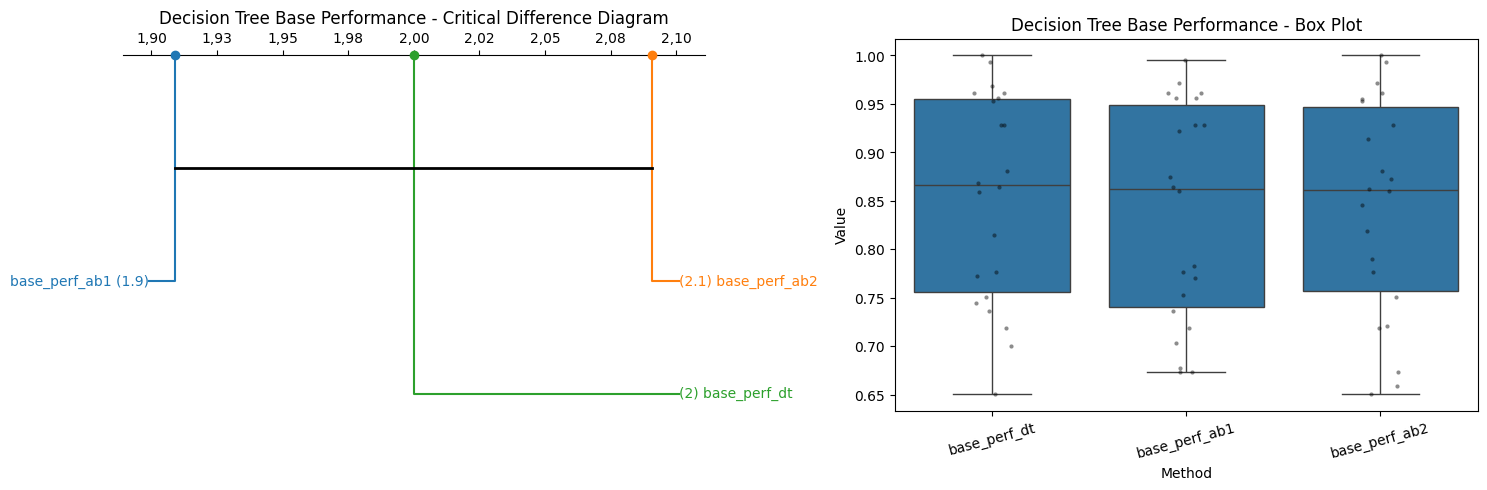

Average ranks (Decision Tree SRC) [0,00 format]:
  src_ab1: 1,55
  src_ab2: 1,45


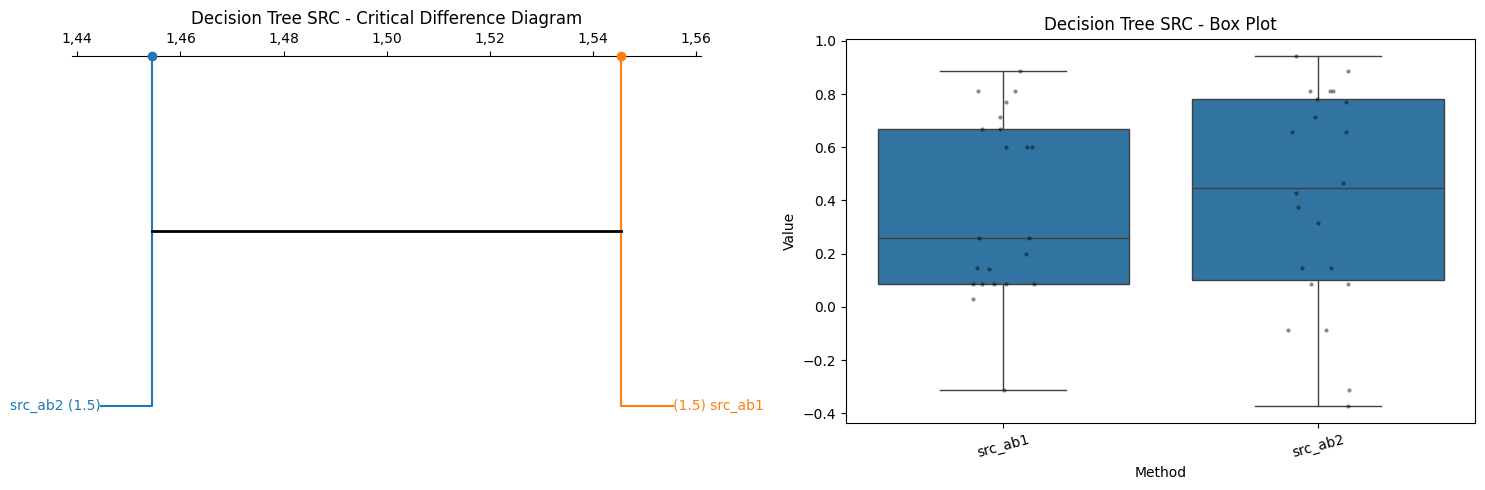

In [ ]:
import scikit_posthocs as sp
from scipy.stats import ttest_rel
from matplotlib.ticker import FuncFormatter

def plot_cd_and_box(df, id_col, title_prefix):
    method_cols = [c for c in df.columns if c != id_col]
    n_methods = len(method_cols)

    # Average ranks (higher value = better, so ascending=False)
    ranks = df[method_cols].rank(axis=1, ascending=False, method='average')
    avg_ranks = ranks.mean(axis=0)

    # Print average ranks in 0,00 format
    avg_ranks_fmt = avg_ranks.map(lambda x: f'{x:.2f}'.replace('.', ','))
    print(f'Average ranks ({title_prefix}) [0,00 format]:')
    for method in avg_ranks_fmt.index:
        print(f'  {method}: {avg_ranks_fmt[method]}')

    # Significance matrix needed by CD diagram
    if n_methods >= 3:
        p_matrix = sp.posthoc_nemenyi_friedman(df[method_cols].values)
        p_matrix.index = method_cols
        p_matrix.columns = method_cols
    else:
        m1, m2 = method_cols
        _, p = ttest_rel(df[m1], df[m2], nan_policy='omit')
        p_matrix = pd.DataFrame(
            [[1.0, p], [p, 1.0]],
            index=method_cols,
            columns=method_cols
        )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1) Critical Difference Diagram
    sp.critical_difference_diagram(avg_ranks, p_matrix, ax=axes[0])
    axes[0].set_title(f'{title_prefix} - Critical Difference Diagram')
    axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'.replace('.', ',')))

    # 2) Box Plot
    long_df = df.melt(id_vars=id_col, value_vars=method_cols, var_name='Method', value_name='Value')
    sns.boxplot(data=long_df, x='Method', y='Value', ax=axes[1])
    sns.stripplot(data=long_df, x='Method', y='Value', color='black', alpha=0.45, size=3, ax=axes[1])
    axes[1].set_title(f'{title_prefix} - Box Plot')
    axes[1].set_xlabel('Method')
    axes[1].set_ylabel('Value')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

# Base performance plots (Decision Tree)
plot_cd_and_box(
    df=base_perf_matrix,
    id_col='Dataset',
    title_prefix='Decision Tree Base Performance'
 )

# SRC plots (Decision Tree)
plot_cd_and_box(
    df=src_matrix,
    id_col='Dataset',
    title_prefix='Decision Tree SRC'
 )

Average ranks (SVM Base Performance) [0,00 format]:
  base_perf_svm_cls: 2,09
  base_perf_svm_ab1: 1,98
  base_perf_svm_ab2: 1,93


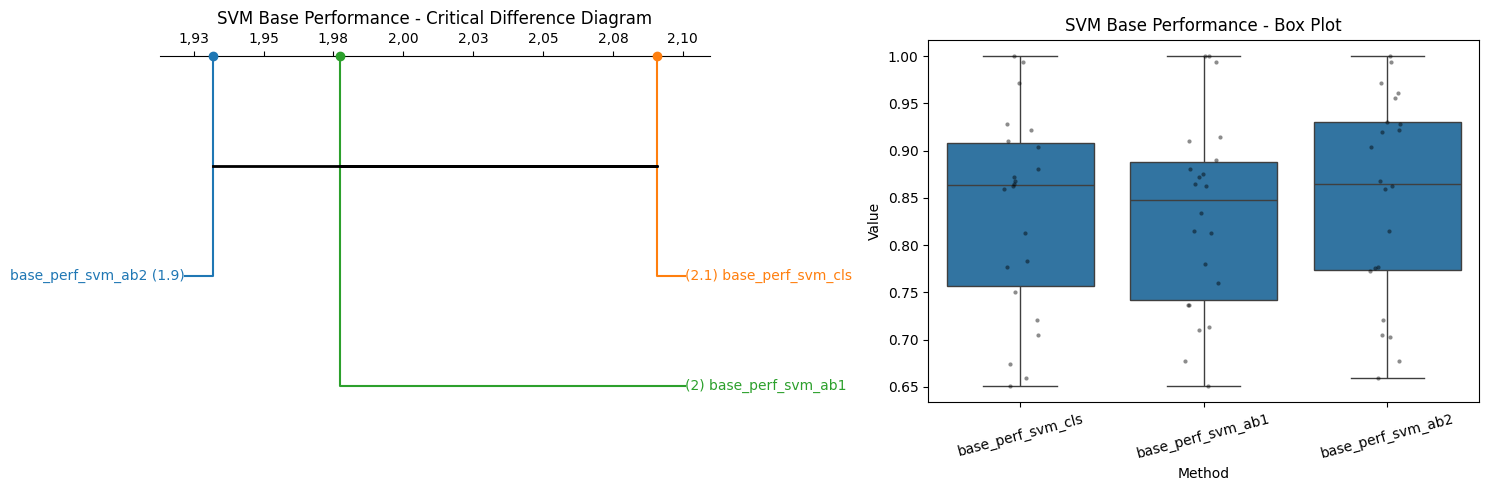

Average ranks (SVM SRC) [0,00 format]:
  src_svm_ab1: 1,68
  src_svm_ab2: 1,32


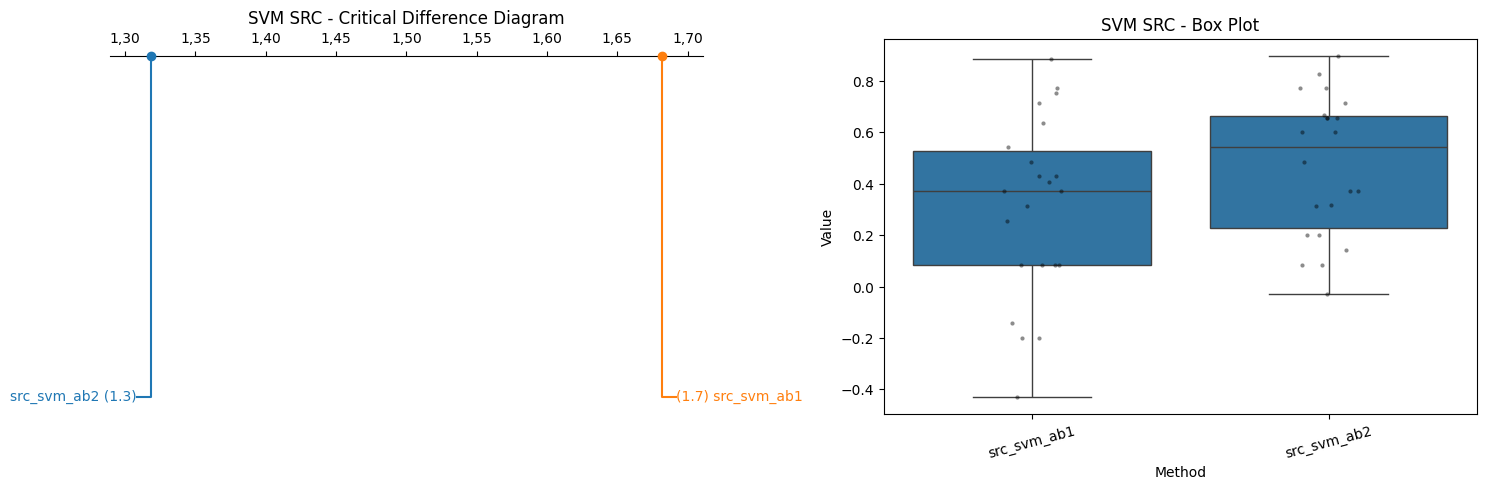

In [ ]:
# Base performance plots (SVM)
plot_cd_and_box(
    df=svm_base_perf_matrix,
    id_col='Dataset',
    title_prefix='SVM Base Performance'
 )

# SRC plots (SVM)
plot_cd_and_box(
    df=svm_src_matrix,
    id_col='Dataset',
    title_prefix='SVM SRC'
 )

# 10. Conclusões:


Este relatório apresenta uma comparação estatística de três abordagens de meta-learning aplicadas a dois modelos base — **Decision Tree** e **SVM** — em 22 datasets. As três abordagens avaliadas são:

- **Classificação** — Decision Tree Classifier que prediz diretamente o melhor algoritmo
- **Regressão (Abordagem 1 - Ab1)** — Decision Tree Regressor treinado com valores de performance
- **Regressão em Ranks (Abordagem 2 - Ab2)** — Decision Tree Regressor treinado com valores de rank

Foram usadas duas métricas de avaliação:

- **Base Performance** — acurácia do classificador recomendado por cada meta-modelo no dataset base
- **Spearman Rank Correlation (SRC)** — correlação entre o ranking predito e o ranking real dos classificadores (aplicável apenas a Ab1 e Ab2)

---

## 1. Modelo: Decision Tree

### 1.1 Normalidade

Os testes de Shapiro-Wilk mostraram que as distribuições de base performance **nao sao normais** para pelo menos uma abordagem. Por isso, testes não paramétricos foram aplicados para ambas as métricas.

### 1.2 Base Performance — Teste de Friedman

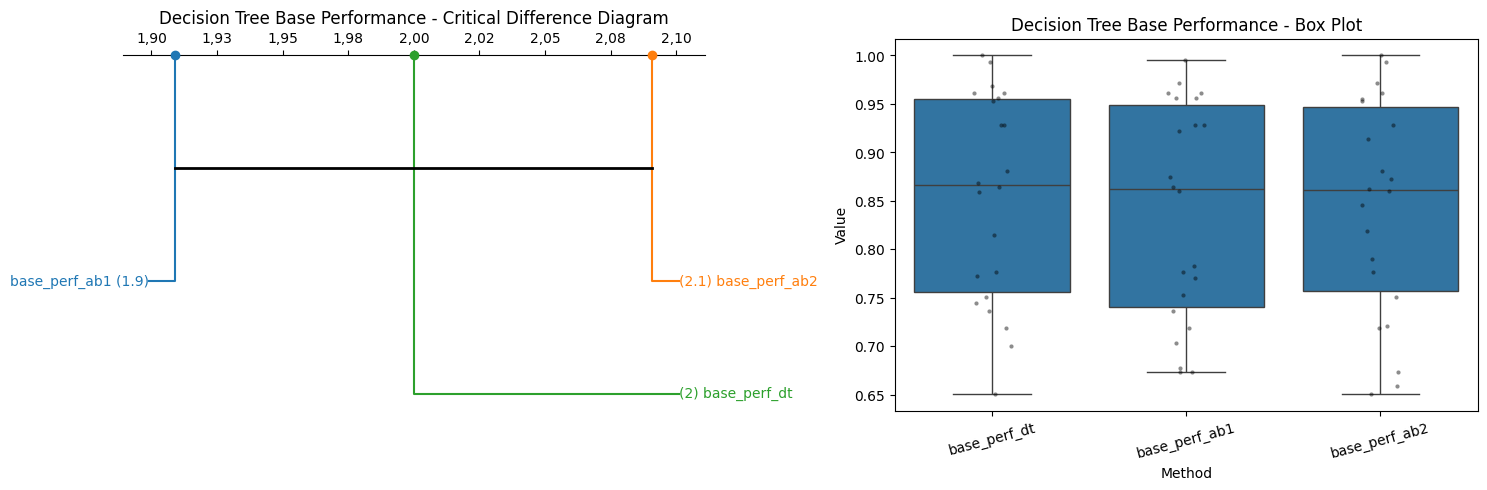

Não foi encontrada diferença estatisticamente significativa entre as três abordagens (p > 0,05).

### 1.3 SRC — Teste de Wilcoxon Signed-Rank

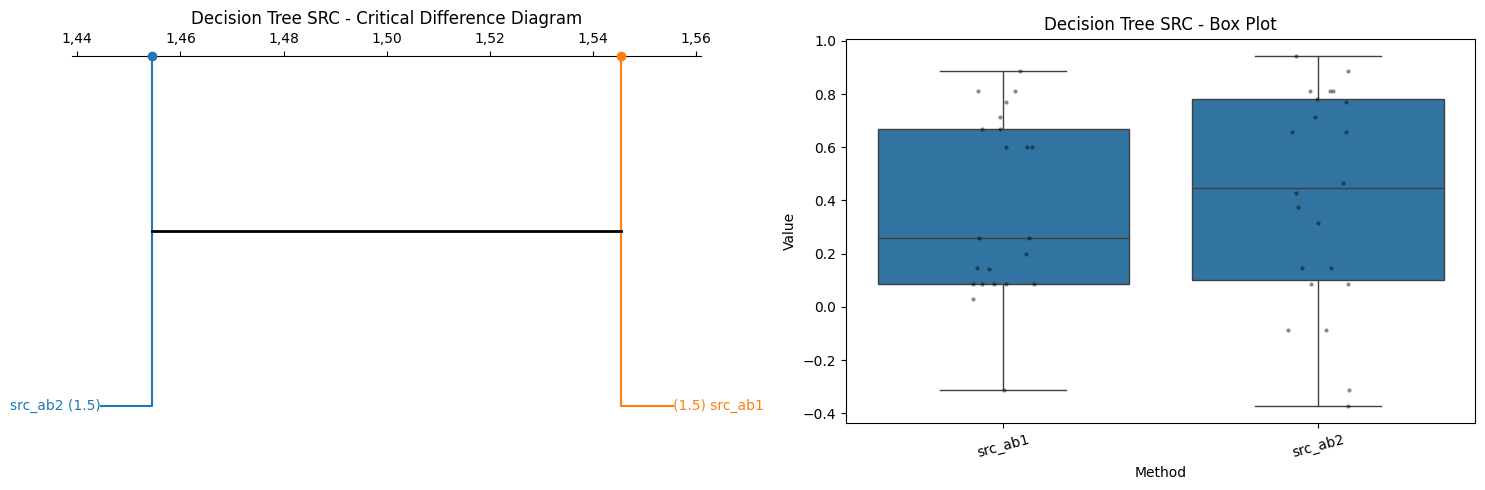

Não foi encontrada diferença estatisticamente significativa entre Ab1 e Ab2 em qualidade de ranking (p > 0,05).

### 1.4 Resumo

As três abordagens de meta-modelo são estatisticamente equivalentes para o aprendiz base Decision Tree, tanto em desempenho do classificador recomendado quanto em qualidade de ranking. A escolha entre abordagens não pode ser justificada apenas por performance; outros critérios, como tempo de treino ou interpretabilidade, devem orientar a decisão.

---

## 2. Modelo: SVM

### 2.1 Normalidade

Os testes de Shapiro-Wilk confirmaram que as distribuições de todas as abordagens são **normais** para ambas as métricas. Portanto, foram aplicados testes paramétricos.

### 2.2 Base Performance — ANOVA de Medidas Repetidas

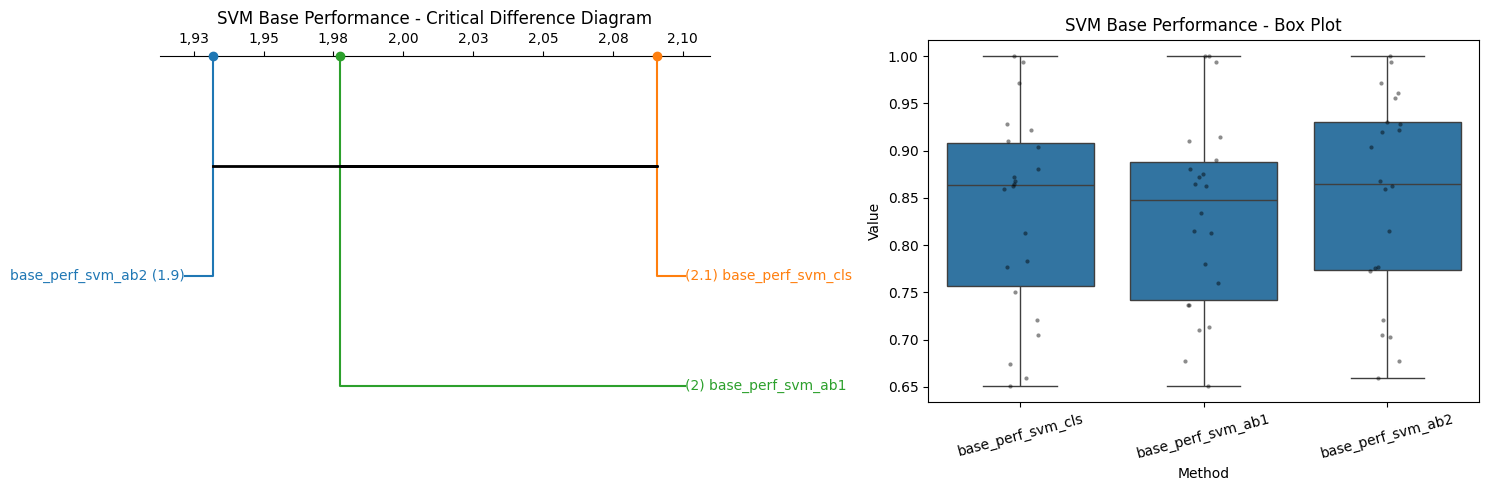

Não foi encontrada diferença estatisticamente significativa entre as três abordagens (p = 0,337, eta2 = 0,005).

### 2.3 SRC — Teste t Pareado

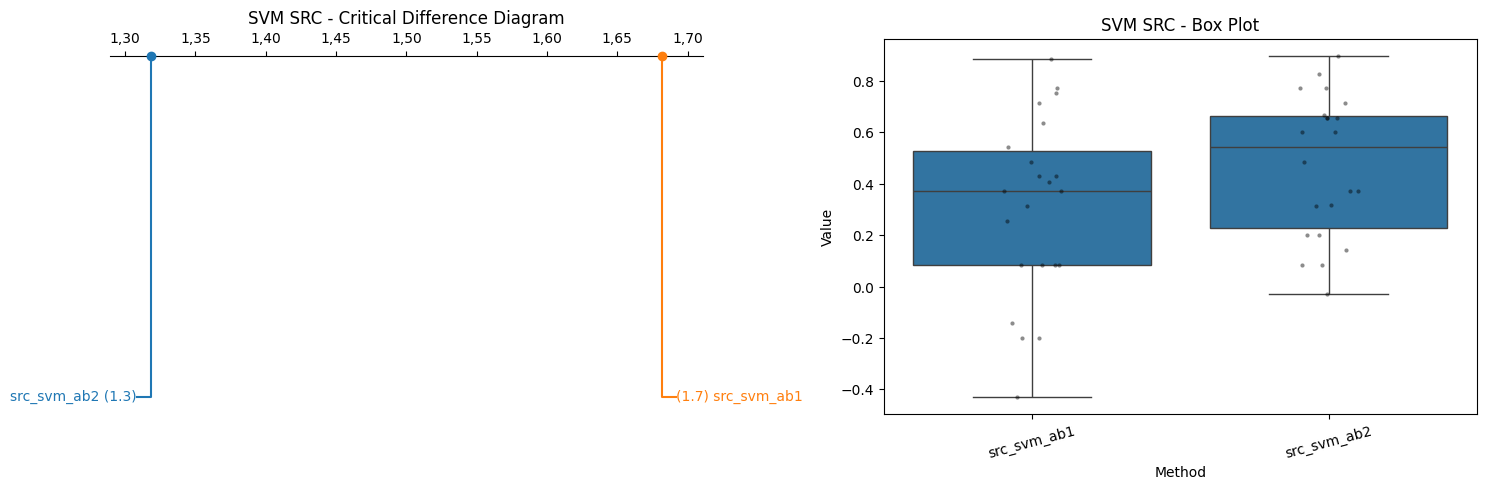

Foi encontrada diferença estatisticamente significativa entre Ab1 e Ab2 (t = -2,155, p = 0,043).

### 2.4 Resumo

Embora o desempenho base permaneça estatisticamente equivalente entre as tres abordagens, **a abordagem de ranking importa** quando o objetivo e ordenar corretamente os classificadores. A Ab2 deve ser preferida a Ab1 quando a qualidade do ranking for prioridade e o aprendiz base for SVM.

---

## 3. Conclusões Gerais

| Comparacao | Decision Tree | SVM |
|---|---|---|
| Base Performance (3 abordagens) | Sem diferença significativa | Sem diferença significativa |
| SRC (Ab1 vs Ab2) | Sem diferença significativa | **Ab2 significativamente melhor** |

O principal achado e que **a escolha do alvo da regressão (valores de performance vs valores de rank) nessa base de dados só faz diferença relevante para os modelos SVM**, em que treinar com ranks leva a uma qualidade de ranking significativamente melhor. Já para os modelos de Decision Tree, as abordagens não apresentam diferenças significativas nas duas métricas.

Esses resultados sugerem que, quando o objetivo do meta-learning e **seleção de classificador** (escolher apenas o melhor), as três abordagens são adequadas. Quando o objetivo e **ranking de classificadores** (ordenar todas as opções), a abordagem 2 é a escolha mais robusta para a base, especialmente para modelos SVM.

